In [ ]:
%pip install kagglehub pandas matplotlib

1. Remove 41 users found this comment useful
2. Remove HTML
3. Remove URL
4. Remove stop words for SVC / LSTM & WordNetLemmatizer

5. LSTM + FastText (embeddings)


In [2]:
DATASET_DIR = "./data"
DATASET_PATH = f"{DATASET_DIR}/drugsComTrain_raw.csv"

In [3]:
downloaded_path = kagglehub.dataset_download(
    "jessicali9530/kuc-hackathon-winter-2018",
    output_dir=DATASET_DIR,
)

print(f"Downloaded dataset to {downloaded_path}")

Downloaded dataset to ./data


In [4]:
df = pd.read_csv(DATASET_PATH)
df_test = pd.read_csv(f"{DATASET_DIR}/drugsComTest_raw.csv")
df[["condition", "review", "date", "usefulCount"]].head(10)

,condition,review,date,usefulCount
0,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",20-May-12,27
1,ADHD,"""My son is halfway through his fourth week of ...",27-Apr-10,192
2,Birth Control,"""I used to take another oral contraceptive, wh...",14-Dec-09,17
3,Birth Control,"""This is my first time using any form of birth...",3-Nov-15,10
4,Opiate Dependence,"""Suboxone has completely turned my life around...",27-Nov-16,37
5,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard...",28-Nov-15,43
6,Emergency Contraception,"""He pulled out, but he cummed a bit in me. I t...",7-Mar-17,5
7,Bipolar Disorde,"""Abilify changed my life. There is hope. I was...",14-Mar-15,32
8,Epilepsy,""" I Ve had nothing but problems with the Kepp...",9-Aug-16,11
9,Birth Control,"""I had been on the pill for many years. When m...",8-Dec-16,1


In [5]:
print(f"Original size of Training dataset: {len(df)} records...")
print(f"Original size of Testing dataset: {len(df_test)} records...")

Original size of Training dataset: 161297 records...
Original size of Testing dataset: 53766 records...


In [6]:
mask = df["review"].str.contains("41 ", case=False, na=False)
df[mask]

,uniqueID,drugName,condition,review,rating,date,usefulCount
317,91431,Anastrozole,Breast Cance,"""I have been on anastozole for a year and half...",6,27-Jun-16,40
597,155648,Metronidazole,Clostridial Infection,"""I am taking this for C-diff. The medicine st...",6,2-Jan-13,13
1500,76751,Lorcaserin,Obesity,"""I think belviq pretty much saved my life! I h...",10,30-Jun-16,39
1805,170812,Quetiapine,Bipolar Disorde,"""I have bipolar II. It took until I was 41 yea...",9,16-Jun-13,10
2260,10274,Breo Ellipta,Asthma,"""I&#039;m 41 and was diagnosed with Asthma at ...",10,22-Aug-17,12
...,...,...,...,...,...,...,...
158153,38101,Aliskiren,High Blood Pressure,"""I&#039;m a 41 year old black male, and this w...",9,5-Dec-09,23
158358,46170,Repatha,"High Cholesterol, Familial Heterozygous","""I had a heart attack in 2014, my doctor put m...",10,11-Feb-16,37
159062,119537,Testosterone,"Hypogonadism, Male","""I have been using the Androderm 2.5 patch for...",7,25-Dec-11,37
160059,4940,Belviq,Weight Loss,"""Slimmed down from 5&quot;2, 188 pounds. In se...",10,27-May-14,97


In [7]:
print(f"Dataset has {len(df["condition"].unique())} unique conditions")

Dataset has 885 unique conditions


In [8]:
top_categories = df["condition"].value_counts().nlargest(10).index

df_top_records = df[df["condition"].isin(top_categories)]

print(f"Number of records in top categories: {len(df_top_records)}")
print(f"Percentage of records in top categories: {len(df_top_records) / len(df) * 100:.2f}%")

Number of records in top categories: 73951
Percentage of records in top categories: 45.85%


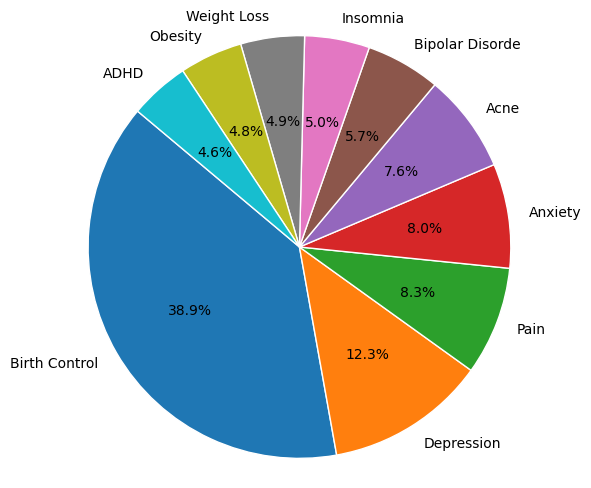

In [9]:
condition_counts = df["condition"].value_counts().nlargest(10)

plt.figure(figsize=(6,6))
plt.pie(
    condition_counts,
    labels=condition_counts.index,
    autopct='%1.1f%%', 
    startangle=140,
    wedgeprops={'edgecolor': 'white'},
)

plt.axis("equal")  # Equal aspect ratio ensures pie is drawn as a circle.

plt.show()

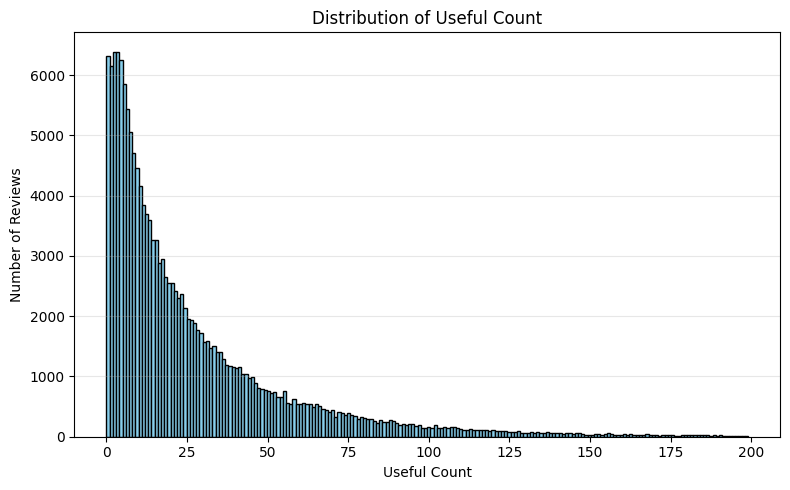

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["usefulCount"] < 200]["usefulCount"], bins=200, color="skyblue", edgecolor="black")
plt.title("Distribution of Useful Count")
plt.xlabel("Useful Count")
plt.ylabel("Number of Reviews")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
df_top_records["usefulCount"].describe().astype(int)

count    73951
mean        26
std         39
min          0
25%          5
50%         13
75%         33
max       1291
Name: usefulCount, dtype: int64

In [12]:
reviews = df_top_records["review"].astype(str)
char_len = reviews.str.len()
word_len = reviews.str.split().str.len()

print("Character length:")
print(char_len.describe().astype(int))
print("\nWord count:")
print(word_len.describe().astype(int))
print(f"\nMissing/empty: {reviews.isna().sum()} na, {(reviews.str.strip() == '').sum()} empty")
print(f"Duplicates: {reviews.duplicated().sum()}")

Character length:
count    73951
mean       493
std        232
min          3
25%        308
50%        506
75%        717
max       5723
Name: review, dtype: int64

Word count:
count    73951
mean        91
std         43
min          1
25%         57
50%         94
75%        131
max       1107
Name: review, dtype: int64

Missing/empty: 0 na, 0 empty
Duplicates: 23824


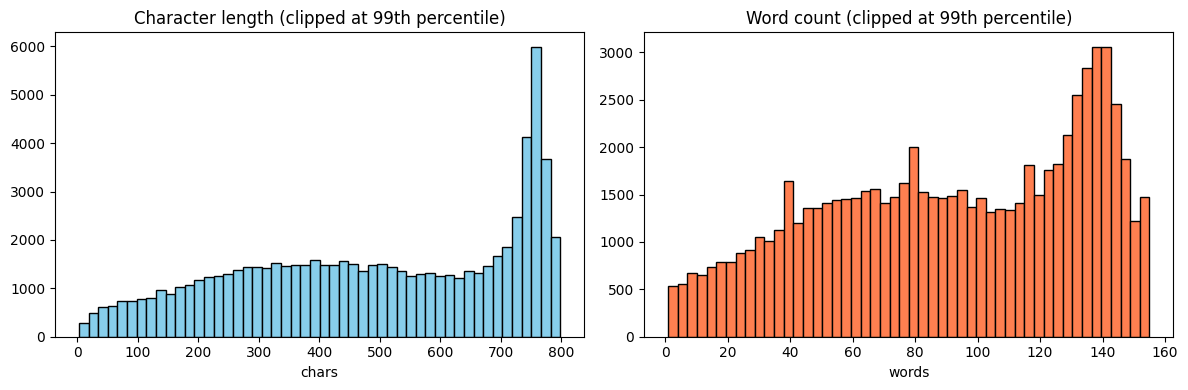

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(char_len.clip(upper=char_len.quantile(0.99)), bins=50, color="skyblue", edgecolor="black")
axes[0].set_title("Character length (clipped at 99th percentile)")
axes[0].set_xlabel("chars")
axes[1].hist(word_len.clip(upper=word_len.quantile(0.99)), bins=50, color="coral", edgecolor="black")
axes[1].set_title("Word count (clipped at 99th percentile)")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()

In [14]:
MIN_USEFUL_COUNT = 3
MIN_CHAR_LENGTH = 20

filtered_df = df_top_records[
    (df_top_records["usefulCount"] > MIN_USEFUL_COUNT)
    & (df_top_records["review"].str.len() > MIN_CHAR_LENGTH)
]
filtered_df = (
    filtered_df
    .drop_duplicates(subset=["review"], keep="first")
    .reset_index(drop=True)
)

min_class_size = filtered_df['condition'].value_counts().min()
max_size_per_category = int(min_class_size * 1.7)

print(f"Balancing everything to the max size per category: '{max_size_per_category}' records")

balanced_df = pd.concat(
    [
        group.sample(min(len(group), max_size_per_category) , random_state=42)
        for _, group in filtered_df.groupby("condition")
    ],
    ignore_index=True,
)

# Shuffling
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

Balancing everything to the max size per category: '3522' records


In [17]:
import re
import html

def clean_review(text: str) -> str:
    if pd.isna(text):
        return ""

    text = str(text)
    # Decode HTML entities (&#039; -> ', &amp; -> &, etc.)
    text = html.unescape(text)
    # Remove HTML tags (<br>, <div>, etc.)
    text = re.sub(r"<[^>]+>", " ", text)
    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

balanced_df["review"] = balanced_df["review"].apply(clean_review)

In [18]:
print(f"The final dataset has {len(balanced_df)} records")

The final dataset has 29489 records


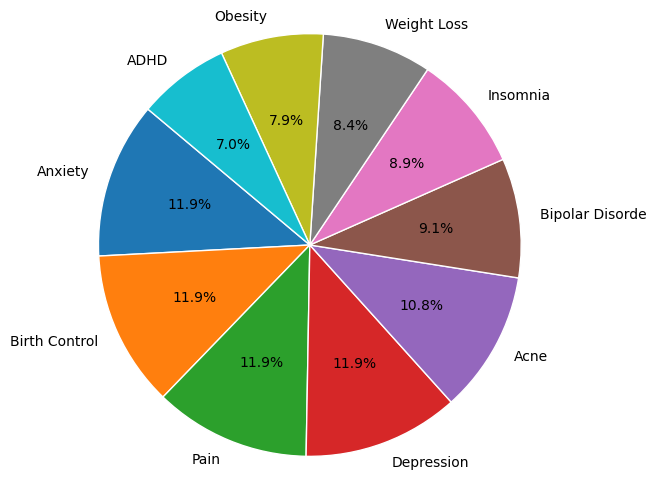

In [19]:
condition_counts = balanced_df["condition"].value_counts().nlargest(10)

plt.figure(figsize=(6,6))
plt.pie(
    condition_counts,
    labels=condition_counts.index,
    autopct='%1.1f%%', 
    startangle=140,
    wedgeprops={'edgecolor': 'white'},
)

plt.axis("equal")  # Equal aspect ratio ensures pie is drawn as a circle.

plt.show()

In [20]:
top_categories = balanced_df["condition"].value_counts().nlargest(10).index

df_test_balanced = df_test[
    df_test["condition"].isin(top_categories)
]
df_test_balanced = (
    df_test_balanced
    .drop_duplicates(subset=["review"], keep="first")
    .reset_index(drop=True)
    .dropna(subset=["review"])
)
df_test_balanced["review"] = df_test_balanced["review"].apply(clean_review)

print(f"The final training dataset has {len(balanced_df)} records")
print(f"The final testing dataset has {len(df_test_balanced)} records")

The final training dataset has 29489 records
The final testing dataset has 22070 records


In [21]:
balanced_df.to_csv(f"{DATASET_DIR}/balanced_train.csv", index=False)
df_test_balanced.to_csv(f"{DATASET_DIR}/balanced_test.csv", index=False)